In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("Powerplant_dataset.csv")

In [4]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [ ]:
# AT - temperature
# V - vaccum
# AP - pressure
# RH - humadity
# PE - produced energy


In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [7]:
# split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [8]:
df.shape

(9568, 5)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [11]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [12]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Deep Learning

In [13]:
# Define ANN Model
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
    
        self.model = nn.Sequential(
            # 1st Hidden Layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            # 2nd Hidden Layer
            nn.Linear(6, 6),
            nn.ReLU(),

            # output Layer
            nn.Linear(6, 1),
        )
    
    def forward(self, x):
        return self.model(x)

In [14]:
import torch.optim as optim
model = ANN()

# loss, optimizer

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [15]:
# Train the ANN
train_losses = []
val_losses = []
best_val_loss = float("inf")
epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch

    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()

        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = criterion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update

        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")
    
    # save model
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") # pt is file extension

epoch 1/100 ==> train loss = 205571.59798177084 & val loss = 202280.39010416667
epoch 2/100 ==> train loss = 190233.81106770833 & val loss = 171169.95546875
epoch 3/100 ==> train loss = 140988.3255859375 & val loss = 107463.00481770834
epoch 4/100 ==> train loss = 76608.70415039062 & val loss = 51254.049609375
epoch 5/100 ==> train loss = 36909.92049967448 & val loss = 27182.997005208334
epoch 6/100 ==> train loss = 21986.080631510416 & val loss = 18212.319905598957
epoch 7/100 ==> train loss = 15621.709891764323 & val loss = 13292.134700520834
epoch 8/100 ==> train loss = 11375.57069905599 & val loss = 9539.365218098957
epoch 9/100 ==> train loss = 7992.0748840332035 & val loss = 6545.605257161458
epoch 10/100 ==> train loss = 5381.147738647461 & val loss = 4342.6428629557295
epoch 11/100 ==> train loss = 3536.702038574219 & val loss = 2875.6915974934896
epoch 12/100 ==> train loss = 2346.2137130737306 & val loss = 1916.3267618815105
epoch 13/100 ==> train loss = 1555.3609138488769 & 

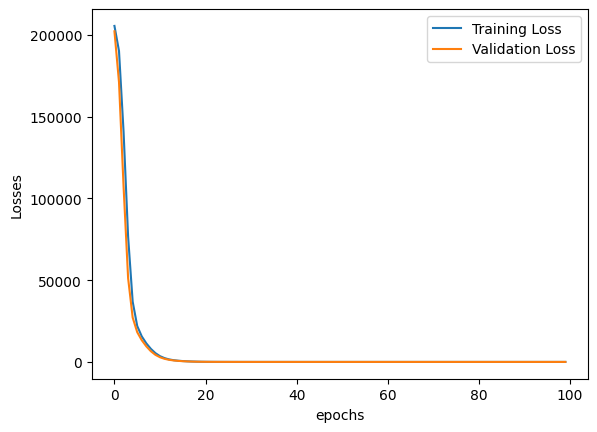

In [16]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})
plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("epochs")
plt.ylabel("Losses")
plt.legend()


In [17]:
# load the best model (saved model)
model.load_state_dict(torch.load("best_model.pt"))


<All keys matched successfully>

In [18]:
# Evaluate Model
model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)

    train_mse_loss = criterion(train_pred, y_train_tensor)
    test_mse_loss = criterion(test_pred, y_test_tensor)

print("Training MSE Loss: ", train_mse_loss.item())
print("Testing MSE Loss", test_mse_loss.item())

Training MSE Loss:  21.333486557006836
Testing MSE Loss 19.589956283569336


In [19]:
from sklearn.metrics import r2_score
print("R2 Score: ", r2_score(y_test, test_pred))

R2 Score:  0.9315381590172408


In [20]:
predicted_df = pd.DataFrame(test_pred.numpy(), columns=["predicted values"])
actual_df = pd.DataFrame(y_test.values, columns=["actual values"])
pd.concat([predicted_df, actual_df], axis=1)

,predicted values,actual values
0,435.233154,433.27
1,437.389954,438.16
2,460.891052,458.42
3,475.795074,480.82
4,435.516357,441.41
...,...,...
1909,451.164246,456.70
1910,431.919800,438.04
1911,467.067780,467.80
1912,431.494934,437.14
